# 01. GCN

This notebook trains a `GCN` node-classification model on the sampled wash-trading graph.

Included by default:

- stratified train/val/test split
- train-time early stopping
- threshold tuning on validation set
- rich test metrics
- loss curves, ROC curve, PR curve, confusion matrix, score histogram, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- node features are used without explicit graph-stat columns


In [28]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from graph_model_utils import (
    build_graph_dataset,
    classification_report_df,
    evaluate_probabilities,
    find_best_threshold,
    get_model,
    plot_evaluation_dashboard,
    plot_training_history,
    predict_probabilities,
    set_seed,
    train_model,
)


In [29]:
MODEL_NAME = "gcn"
FEATURE_GROUP = "eth_twitter_combined_features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
HIDDEN_DIM = 64
DROPOUT = 0.2
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
PATIENCE = 15
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [30]:
data = build_graph_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([data["graph_summary"]]))
display(data["split_df"])
print("Device:", data["device"])
print("Number of input features:", len(data["feature_cols"]))


,num_nodes,num_edges,num_features,positive_nodes,negative_nodes,has_self_loops_after_build
0,10000,283909,24,1126,8874,True


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Device: cpu
Number of input features: 24


In [31]:
model = get_model(
    model_name=MODEL_NAME,
    in_dim=data["features"].shape[1],
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", parameter_count)


GCNModel(
  (conv1): GraphConv(in=24, out=64, normalization=both, activation=None)
  (conv2): GraphConv(in=64, out=64, normalization=both, activation=None)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Trainable parameters: 5890


,epoch,train_loss,val_loss,val_threshold,train_Threshold,train_PR-AUC,train_ROC-AUC,train_F1,train_Precision,train_Recall,...,val_Brier-Score,val_Log-Loss,val_Accuracy,val_TP,val_FP,val_TN,val_FN,val_TopK,val_Precision@K,val_Recall@K
34,35,0.511608,0.510710,0.55,0.55,0.731119,0.925884,0.686930,0.659277,0.717005,...,0.206903,0.601447,0.923333,116,62,1269,53,169,0.662722,0.662722
35,36,0.509327,0.507963,0.55,0.55,0.730820,0.925438,0.683162,0.651323,0.718274,...,0.206132,0.599845,0.923333,117,63,1268,52,169,0.662722,0.662722
36,37,0.505965,0.505322,0.55,0.55,0.730664,0.924947,0.681490,0.647260,0.719543,...,0.205331,0.598203,0.921333,117,66,1265,52,169,0.662722,0.662722
37,38,0.504544,0.502778,0.55,0.55,0.730288,0.924378,0.680215,0.642938,0.722081,...,0.204475,0.596474,0.921333,117,66,1265,52,169,0.662722,0.662722
38,39,0.502154,0.500322,0.55,0.55,0.730030,0.923824,0.679762,0.640135,0.724619,...,0.203575,0.594677,0.920667,118,68,1263,51,169,0.656805,0.656805


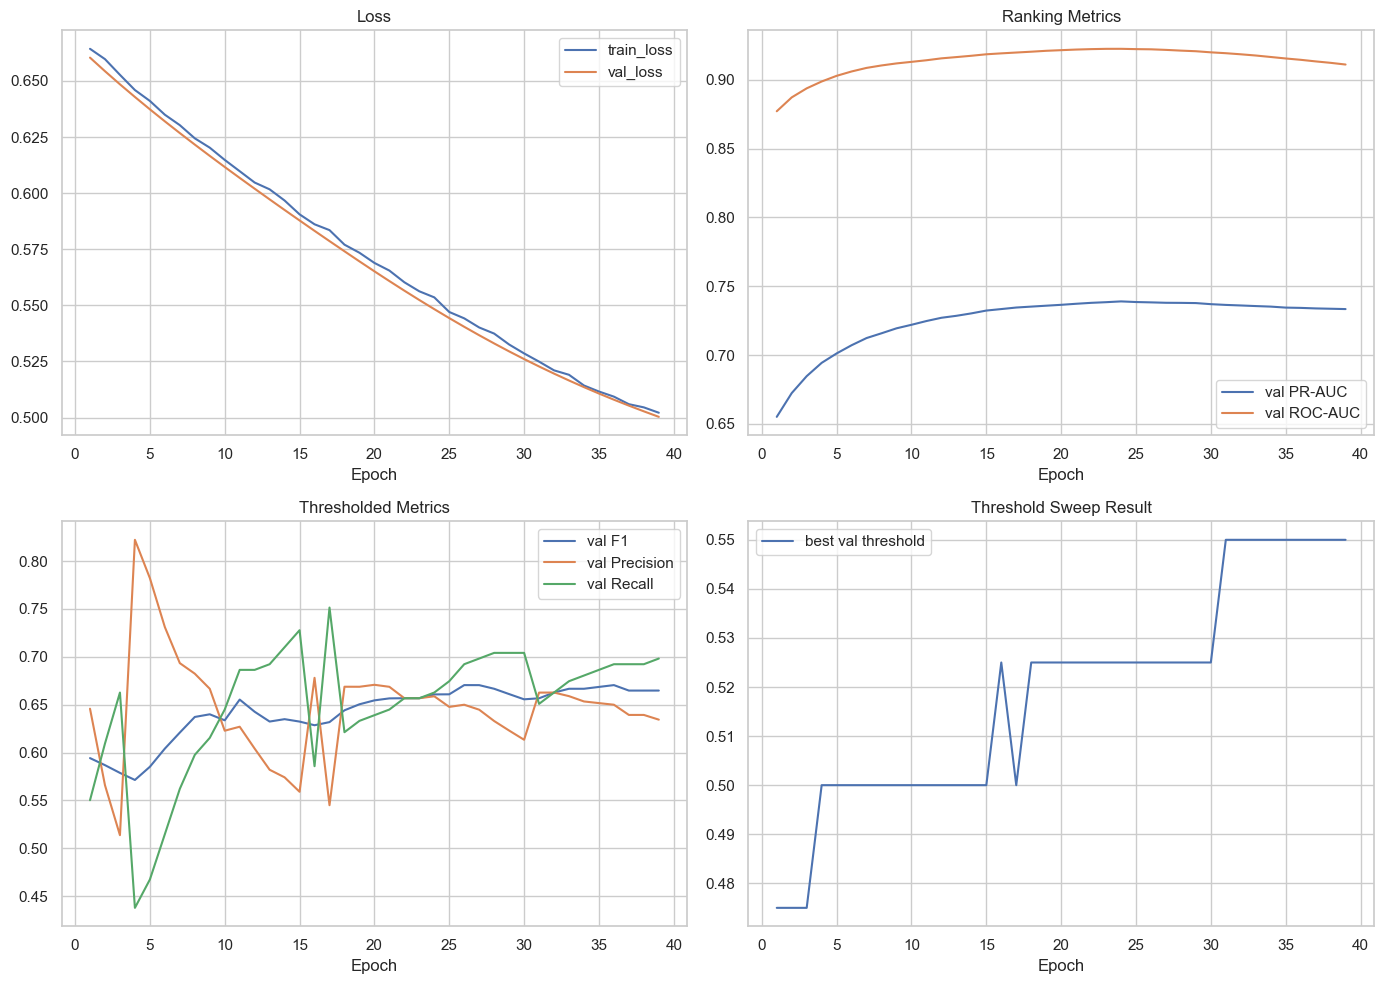

In [32]:
best_model, history_df = train_model(
    model=model,
    data=data,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

display(history_df.tail())
plot_training_history(history_df)


In [33]:
val_true, val_prob = predict_probabilities(best_model, data, "val_mask")
best_threshold = find_best_threshold(val_true, val_prob, objective=THRESHOLD_OBJECTIVE)

test_true, test_prob = predict_probabilities(best_model, data, "test_mask")
test_metrics = evaluate_probabilities(test_true, test_prob, best_threshold)

metrics_df = pd.DataFrame([test_metrics]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.525000
PR-AUC,0.716726
ROC-AUC,0.916642
F1,0.675900
Precision,0.635417
Recall,0.721893
Specificity,0.947408
NPV,0.964067
Balanced-Accuracy,0.834651
MCC,0.633432


In [34]:
report_df = classification_report_df(test_true, test_prob, best_threshold)
display(report_df)


,precision,recall,f1-score,support
0,0.964067,0.947408,0.955665,1331.000
1,0.635417,0.721893,0.675900,169.000
accuracy,0.922000,0.922000,0.922000,0.922
macro avg,0.799742,0.834651,0.815783,1500.000
weighted avg,0.927039,0.922000,0.924145,1500.000


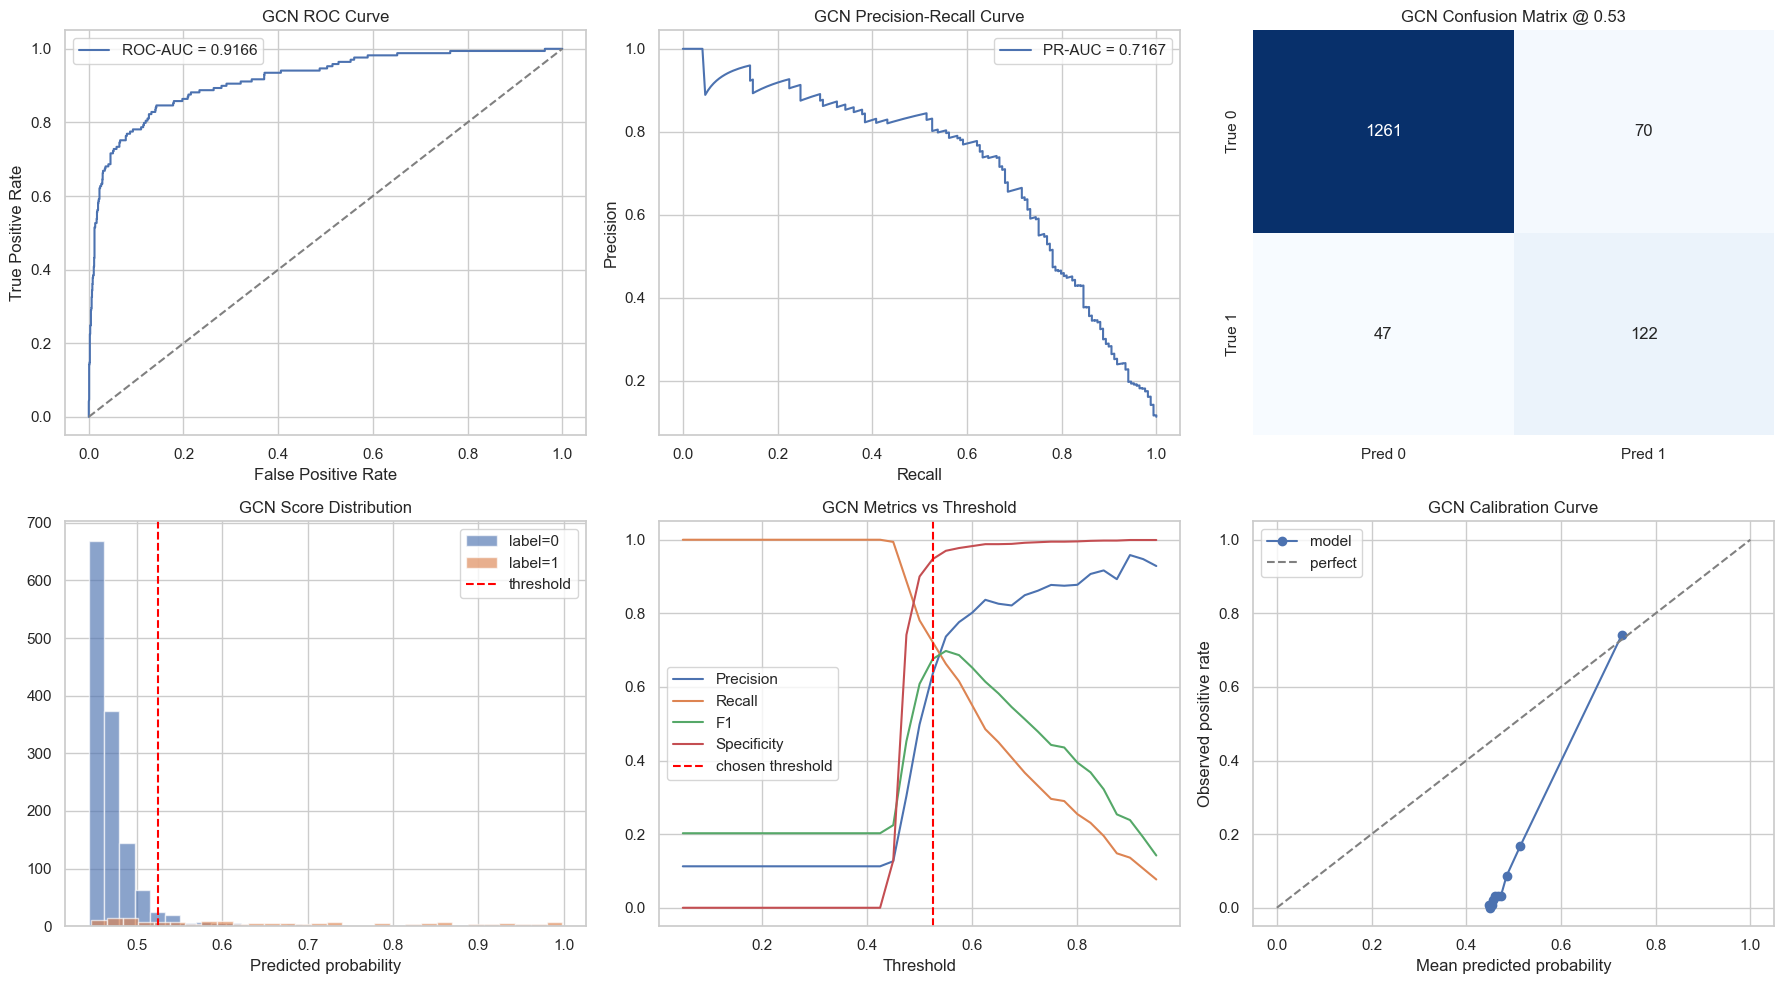

In [35]:
plot_evaluation_dashboard(
    y_true=test_true,
    y_prob=test_prob,
    threshold=best_threshold,
    title_prefix=MODEL_NAME.upper(),
)


In [36]:
test_node_rows = data["nodes_df"].loc[data["test_mask"].detach().cpu().numpy()].copy()
test_node_rows["predicted_probability"] = test_prob
test_node_rows["predicted_label"] = (test_prob >= best_threshold).astype(int)

suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
2046,258361,1,0.998189,1,2,0
2209,276703,1,0.996671,1,1,0
1773,230116,1,0.992801,1,1,0
1807,233182,1,0.989043,1,1,1
1598,210566,1,0.988011,1,1,0
2026,256583,1,0.986202,1,2,1
1520,203021,1,0.981624,1,1,0
2732,341302,1,0.979660,1,4,2
2827,353328,0,0.979660,1,8,2
2754,343737,1,0.972612,1,2,1


## Notes

Keep the reported `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing models.
The threshold comes from validation data and is reused on the test split.
